# 🎵 Los Datos de las Canciones: La Evolución de Taylor Swift
### Un viaje por la música, las emociones y el ritmo a través de los datos de Spotify

**Proyecto práctico de Humanidades y Medios Creativos**  
*Inspirado en la metodología de periodismo de datos de "La Data Cuenta"*

---

### ¿De qué trata este proyecto?
¿Alguna vez te has preguntado por qué algunas canciones nos ponen felices al instante, mientras que otras nos dan ganas de bailar aunque la letra sea triste?

En este proyecto analizamos **184 canciones de Taylor Swift** usando los datos acústicos oficiales de **Spotify**. Exploraremos:
1. **La fórmula del "Sad Banger":** Canciones con ritmo de fiesta pero con melodías melancólicas.
2. **Las canciones récord:** Las más rápidas, lentas, alegres y acústicas de toda su carrera.
3. **El mapa musical:** En qué notas compone más y si prefiere escalas alegres (Modo Mayor) o tristes (Modo Menor).
4. **La duración de sus canciones:** Cómo han cambiado los tiempos de sus temas con la llegada del streaming.

---
## Paso 1: Cargar nuestras herramientas y la base de datos
Usamos **Pandas** para manejar la tabla de canciones, **Matplotlib / Seaborn** para dibujar gráficas elegantes y **Plotly** para hacer mapas interactivos donde puedes pasar el cursor sobre cada canción.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 1. Activamos el estilo moderno de Seaborn para que todas las gráficas se vean profesionales
sns.set_theme(style="whitegrid")

# ---> CAMBIA AQUÍ EL NOMBRE DE TU ARCHIVO CSV <---
archivo_artista = 'taylor_swift_canciones.csv'

# Leemos el archivo
canciones = pd.read_csv(archivo_artista)

print("¡Librerías listas y archivo cargado con éxito!")
print(f"Total de filas leídas: {len(canciones)}")

¡Librerías listas y archivo cargado con éxito!
Total de filas leídas: 184


---
## Paso 2: Limpieza de datos y traducción al lenguaje musical
Las computadoras leen las notas musicales como números del 0 al 11 (donde 0 es Do, 1 es Do#, etc.) y la duración en milisegundos.

En esta celda:
* Limpiamos canciones repetidas para quedarnos con la versión más popular.
* Convertimos la duración a minutos y segundos reales.
* Traducimos las notas y los modos (Mayor = alegre / Menor = melancólico).
* Calculamos el **Índice para Bailar Llorando (Sad Banger)**: combina mucho ritmo (danceability) y energía con un tono melancólico (valence bajo).

In [ ]:
# 1. Si hay canciones repetidas, nos quedamos con la más popular
if 'popularity' in canciones.columns:
    canciones = canciones.sort_values(by='popularity', ascending=False)

# Buscamos la columna que represente el nombre de la canción de forma segura
columna_nombre = None
for col in ['track_name', 'name', 'title']:
    if col in canciones.columns:
        columna_nombre = col
        break

if columna_nombre:
    canciones = canciones.drop_duplicates(subset=[columna_nombre]).copy()
else:
    print("Advertencia: No se encontró una columna para identificar el nombre de la canción (como 'track_name'). No se pudieron eliminar duplicados por nombre.")

# 2. Convertir duración a segundos y minutos
if 'duration_ms' in canciones.columns:
    canciones['duracion_segundos'] = (canciones['duration_ms'] / 1000).round(1)
    canciones['duracion_minutos'] = (canciones['duracion_segundos'] / 60).round(2)

# 3. Traducir las notas musicales de números a notas reales (0=Do, 1=Do#, etc.)
lista_notas = ['Do (C)', 'Do# (C#)', 'Re (D)', 'Re# (D#)', 'Mi (E)', 'Fa (F)',
               'Fa# (F#)', 'Sol (G)', 'Sol# (G#)', 'La (A)', 'La# (A#)', 'Si (B)']

if 'key' in canciones.columns:
    canciones['nota_musical'] = canciones['key'].map(lambda k: lista_notas[int(k)] if 0 <= k <= 11 else 'Desconocida')

# 4. Traducir Modo (1=Mayor, 0=Menor)
if 'mode' in canciones.columns:
    canciones['modo_musical'] = canciones['mode'].map({1: 'Mayor', 0: 'Menor'})

# 5. Calcular la fórmula de "Bailar Llorando" (Sad Banger)
# Alta bailabilidad + Alta energía + Melancolía musical (1 - valence)
if {'danceability', 'energy', 'valence'}.issubset(canciones.columns):
    ritmo = canciones['danceability'] * 0.4
    potencia = canciones['energy'] * 0.3
    melancolia = (1 - canciones['valence']) * 0.3
    canciones['nivel_bailar_llorando'] = (ritmo + potencia + melancolia).round(2)

print(f"Catálogo limpio listo: {len(canciones)} canciones únicas analizadas.")

Catálogo limpio listo: 184 canciones únicas analizadas.


---
## Paso 3: Top 5 canciones para «Bailar Llorando»
¿Cuáles son las canciones que tienen un ritmo irresistible pero cuya vibra musical es triste o desgarradora? Aquí están las 5 mejores puntuadas con nuestro índice:

In [ ]:
columnas_interes = ['track_name', 'danceability', 'energy', 'valence', 'nivel_bailar_llorando']
if 'nota_musical' in canciones.columns:
    columnas_interes.append('nota_musical')

# Validamos si la columna existe antes de intentar ordenar y mostrar
if 'nivel_bailar_llorando' in canciones.columns:
    print("=== TOP 5 CANCIONES PARA 'BAILAR LLORANDO' ===")
    # Filtramos columnas_interes para asegurar que solo mostramos las que realmente existen en el DataFrame
    columnas_validas = [col for col in columnas_interes if col in canciones.columns]
    display(canciones.sort_values(by='nivel_bailar_llorando', ascending=False)[columnas_validas].head(5))
else:
    print("¡Error! No se puede mostrar el Top porque la columna 'nivel_bailar_llorando' no fue creada.")
    print("Verifica si tu archivo CSV contiene las columnas: 'danceability', 'energy' y 'valence'.")
    print(f"Columnas disponibles actualmente: {list(canciones.columns)}")

=== TOP 5 CANCIONES PARA 'BAILAR LLORANDO' ===


,danceability,energy,valence,nivel_bailar_llorando,nota_musical
147,0.677,0.722,0.0483,0.77,Sol (G)
76,0.824,0.624,0.2480,0.74,Do (C)
20,0.750,0.404,0.0499,0.71,La (A)
83,0.652,0.802,0.2950,0.71,Sol (G)
78,0.712,0.732,0.3130,0.71,Mi (E)


---
## Paso 4: Récords Extremos del Catálogo
Para conocer los límites de la música de Taylor Swift, la computadora busca de manera automática los extremos: la canción más rápida (BPM), la balada más lenta, la más bailable, la más melancólica y la más acústica.

In [ ]:
lista_records = []


col_cancion = columna_nombre if 'columna_nombre' in locals() and columna_nombre in canciones.columns else 'name'

if 'tempo' in canciones.columns:
    mas_rapida = canciones.loc[canciones['tempo'].idxmax()]
    mas_lenta = canciones.loc[canciones['tempo'].idxmin()]
    lista_records.append({'Categoría': 'La más rápida', 'Canción': mas_rapida[col_cancion], 'Dato': f"{mas_rapida['tempo']:.1f} BPM"})
    lista_records.append({'Categoría': 'La más lenta (balada)', 'Canción': mas_lenta[col_cancion], 'Dato': f"{mas_lenta['tempo']:.1f} BPM"})

if 'danceability' in canciones.columns:
    mas_bailable = canciones.loc[canciones['danceability'].idxmax()]
    lista_records.append({'Categoría': 'La más bailable', 'Canción': mas_bailable[col_cancion], 'Dato': f"{mas_bailable['danceability']}"})

if 'valence' in canciones.columns:
    mas_triste = canciones.loc[canciones['valence'].idxmin()]
    mas_alegre = canciones.loc[canciones['valence'].idxmax()]
    lista_records.append({'Categoría': 'La más melancólica (Valence bajo)', 'Canción': mas_triste[col_cancion], 'Dato': f"{mas_triste['valence']}"})
    lista_records.append({'Categoría': 'La más alegre (Valence alto)', 'Canción': mas_alegre[col_cancion], 'Dato': f"{mas_alegre['valence']}"})

if 'acousticness' in canciones.columns:
    mas_acustica = canciones.loc[canciones['acousticness'].idxmax()]
    lista_records.append({'Categoría': 'La más acústica', 'Canción': mas_acustica[col_cancion], 'Dato': f"{mas_acustica['acousticness']}"})

if 'duracion_segundos' in canciones.columns:
    mas_corta = canciones.loc[canciones['duracion_segundos'].idxmin()]
    mas_larga = canciones.loc[canciones['duracion_segundos'].idxmax()]
    lista_records.append({'Categoría': 'La más corta', 'Canción': mas_corta[col_cancion], 'Dato': f"{mas_corta['duracion_segundos']} seg"})
    lista_records.append({'Categoría': 'La más larga', 'Canción': mas_larga[col_cancion], 'Dato': f"{mas_larga['duracion_segundos']} seg"})

tabla_records = pd.DataFrame(lista_records)
print("=== RÉCORDS DEL CATÁLOGO ===")
display(tabla_records)

=== RÉCORDS DEL CATÁLOGO ===


,Categoría,Canción,Dato
0,La más rápida,Soon You’ll Get Better (feat. The Chicks),207.5 BPM
1,La más lenta (balada),Lover,68.5 BPM
2,La más bailable,I Think He Knows,0.897
3,La más melancólica (Valence bajo),Both of Us (feat. Taylor Swift),0.0483
4,La más alegre (Valence alto),Shake It Off,0.942
5,La más acústica,It’s Nice To Have A Friend,0.971
6,La más corta,It’s Nice To Have A Friend,150.4 seg
7,La más larga,Dear John,403.9 seg


---
## Paso 5: ¿En qué notas compone más Taylor Swift?
Esta gráfica de barras cuenta cuántas canciones tiene compuestas en cada nota de la escala. Podemos ver claramente cuáles son sus tonalidades favoritas para componer con su guitarra y piano.

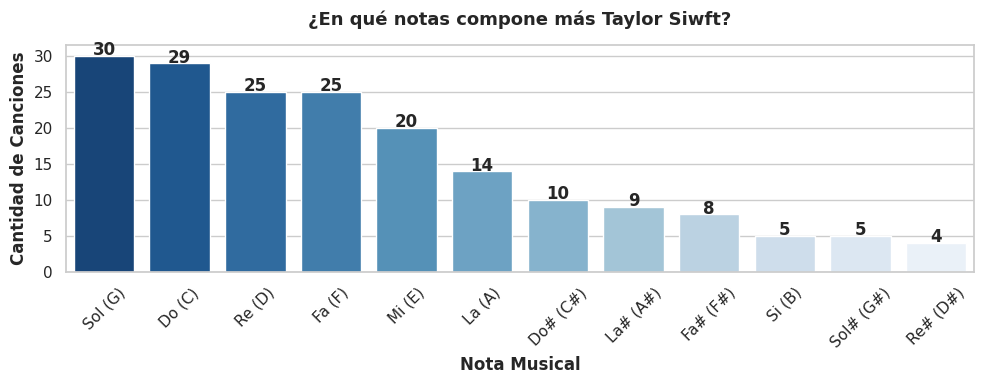

In [ ]:

nombre_artista = "Taylor Siwft"

conteo_notas = canciones['nota_musical'].value_counts().reset_index()
conteo_notas.columns = ['nota', 'cantidad']

plt.figure(figsize=(10, 4))
# Usamos barplot de Seaborn con paleta degradada
grafica_barras = sns.barplot(data=conteo_notas, x='nota', y='cantidad', hue='nota', palette='Blues_r', legend=False)

plt.title(f'¿En qué notas compone más {nombre_artista}?', fontsize=13, weight='bold', pad=15)
plt.xlabel('Nota Musical', weight='bold')
plt.ylabel('Cantidad de Canciones', weight='bold')
plt.xticks(rotation=45)

# Poner el número arriba de cada barra
for i, valor in enumerate(conteo_notas['cantidad']):
    grafica_barras.text(i, valor + 0.1, str(valor), ha='center', weight='bold')

plt.tight_layout()
plt.show()

---
## Paso 6: ¿Alegre o Melancólica? Modo Mayor vs. Modo Menor
En teoría musical:
* El **Modo Mayor** suele sonar brillante, resuelto y alegre.
* El **Modo Menor** suele sonar íntimo, misterioso o melancólico.

Aquí vemos qué porcentaje de su repertorio corresponde a cada uno:

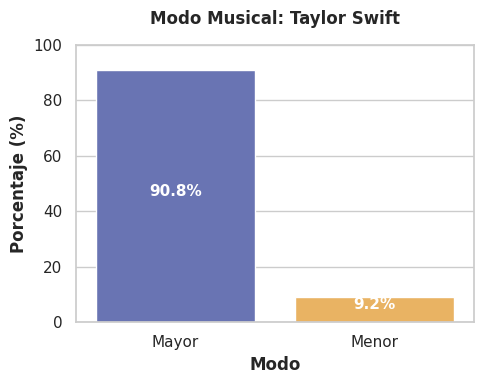

In [ ]:

nombre_artista = "Taylor Swift"

conteo_modos = canciones['modo_musical'].value_counts(normalize=True).mul(100).reset_index()
conteo_modos.columns = ['modo', 'porcentaje']

plt.figure(figsize=(5, 4))
grafica_modo = sns.barplot(data=conteo_modos, x='modo', y='porcentaje', hue='modo', palette=['#5c6bc0', '#ffb74d'], legend=False)

plt.title(f'Modo Musical: {nombre_artista}', fontsize=12, weight='bold', pad=15)
plt.xlabel('Modo', weight='bold')
plt.ylabel('Porcentaje (%)', weight='bold')
plt.ylim(0, 100)

for i, valor in enumerate(conteo_modos['porcentaje']):
    grafica_modo.text(i, valor / 2, f"{valor:.1f}%", ha='center', color='white', weight='bold', fontsize=11)

plt.tight_layout()
plt.show()

---
## Paso 7: Mapa Emocional Interactivo (Positividad vs. Ritmo)
Esta gráfica interactiva ubica cada canción según su tristeza/alegría (eje horizontal) y qué tan bailable es (eje vertical).  
* **Pasa tu cursor sobre cualquier punto** para descubrir el nombre de la canción.  
* **El cuadrante superior izquierdo** muestra los éxitos bailables con letras de desamor o melancolía.

In [ ]:

nombre_artista = "Taylor Swift"

# Usamos el nombre de columna detectado previamente, o por defecto 'name'
col_cancion = columna_nombre if 'columna_nombre' in locals() and columna_nombre in canciones.columns else 'name'

grafica_interactiva = px.scatter(
    canciones,
    x='valence',
    y='danceability',
    hover_name=col_cancion,
    size='popularity' if 'popularity' in canciones.columns else None,
    labels={
        'valence': 'Positividad Musical (0 = Triste / 1 = Alegre)',
        'danceability': 'Qué tan bailable es (0 = Lenta / 1 = Muy Bailable)'
    },
    title=f'<b>Mapa Emocional de {nombre_artista}</b><br><sup>Cuadrante superior izquierdo: canciones tristes pero bailables</sup>'
)

# Líneas guía de cuadrantes
grafica_interactiva.add_vline(x=0.5, line_dash="dash", line_color="gray")
grafica_interactiva.add_hline(y=0.5, line_dash="dash", line_color="gray")

grafica_interactiva.show()

---
## Paso 8: El Top 10 de Canciones Más Escuchadas
¿Cuáles son los 10 temas con el puntaje más alto de popularidad en Spotify dentro de este catálogo?

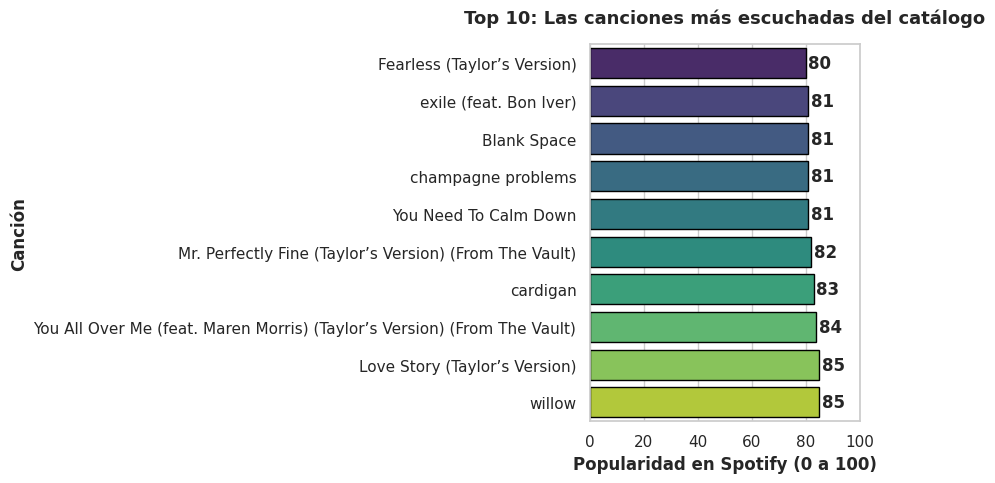

In [ ]:
# 1. Seleccionamos el Top 10 por popularidad
top10 = canciones.sort_values(by='popularity', ascending=True).tail(10)

# Usamos el nombre de columna detectado previamente, o por defecto 'name'
col_cancion = columna_nombre if 'columna_nombre' in locals() and columna_nombre in canciones.columns else 'name'

plt.figure(figsize=(9, 5))
# Gráfica de barras horizontales con Seaborn
barras_top = sns.barplot(
    data=top10,
    x='popularity',
    y=col_cancion,
    hue=col_cancion,
    palette='viridis',
    edgecolor='black'
)

plt.title('Top 10: Las canciones más escuchadas del catálogo', fontsize=13, weight='bold', pad=15)
plt.xlabel('Popularidad en Spotify (0 a 100)', weight='bold')
plt.ylabel('Canción', weight='bold')
plt.xlim(0, 100)

# Escribir el número de popularidad al final de cada barra
for i, valor in enumerate(top10['popularity']):
    barras_top.text(valor + 1, i, str(valor), va='center', weight='bold')

plt.tight_layout()
plt.show()

---
## Paso 9: Termómetro de Energía (Potencia vs. Calma)
Comparamos las 5 canciones más explosivas y ruidosas contra las 5 canciones más suaves y calmadas del repertorio:

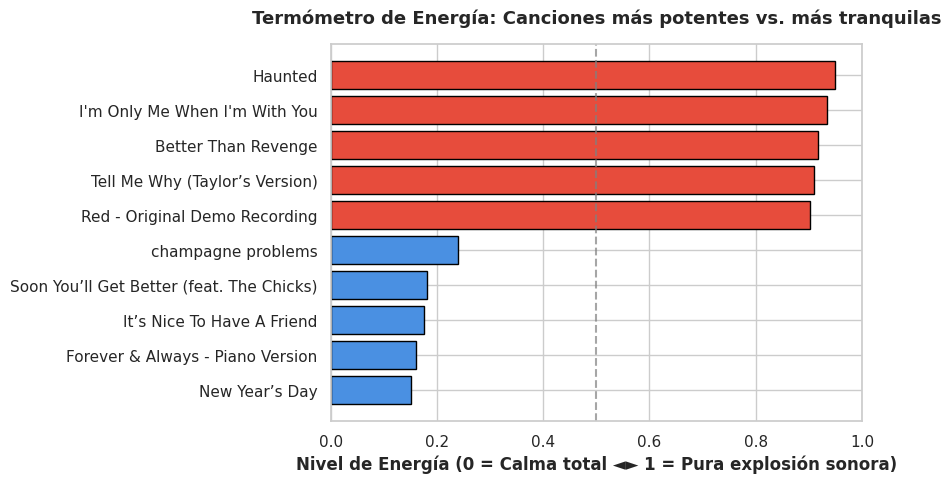

In [ ]:
# 1. Sacamos las 5 con más energía y las 5 con menos energía
mas_energia = canciones.sort_values(by='energy', ascending=False).head(5)
menos_energia = canciones.sort_values(by='energy', ascending=True).head(5)

extremos_energia = pd.concat([mas_energia, menos_energia]).sort_values(by='energy', ascending=True)

# Usamos el nombre de columna detectado previamente, o por defecto 'name'
col_cancion = columna_nombre if 'columna_nombre' in locals() and columna_nombre in canciones.columns else 'name'

plt.figure(figsize=(9, 5))
# Color rojo para las enérgicas y azul para las calmadas
colores = ['#4A90E2' if e < 0.55 else '#E74C3C' for e in extremos_energia['energy']]

plt.barh(extremos_energia[col_cancion], extremos_energia['energy'], color=colores, edgecolor='black')
plt.title('Termómetro de Energía: Canciones más potentes vs. más tranquilas', fontsize=13, weight='bold', pad=15)
plt.xlabel('Nivel de Energía (0 = Calma total ◄► 1 = Pura explosión sonora)', weight='bold')
plt.xlim(0, 1)

# Línea divisoria
plt.axvline(x=0.5, linestyle='--', color='gray', alpha=0.7)

plt.tight_layout()
plt.show()

---
## Paso 10: ¿Qué velocidad predomina? (Ritmo Lento, Medio o Rápido)
Clasificamos las canciones en 3 tipos de velocidad según sus BPM (golpes por minuto):
* **Lenta / Balada:** menos de 100 BPM
* **Ritmo Medio:** entre 100 y 125 BPM
* **Rápida / Enérgica:** más de 125 BPM

/tmp/ipykernel_1808/2247068916.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




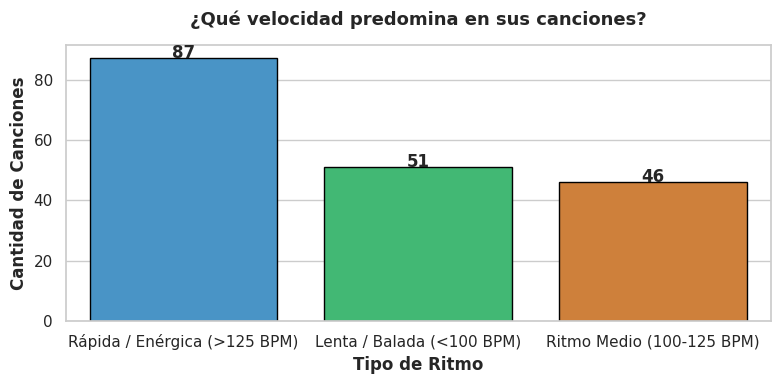

In [ ]:
# 1. Clasificamos las canciones por rangos de BPM
def clasificar_velocidad(bpm):
    if bpm < 100:
        return 'Lenta / Balada (<100 BPM)'
    elif bpm <= 125:
        return 'Ritmo Medio (100-125 BPM)'
    else:
        return 'Rápida / Enérgica (>125 BPM)'

canciones['categoria_ritmo'] = canciones['tempo'].apply(clasificar_velocidad)

# 2. Contamos cuántas hay por categoría
conteo_ritmo = canciones['categoria_ritmo'].value_counts().reset_index()
conteo_ritmo.columns = ['categoria', 'total']

plt.figure(figsize=(8, 4))
sns.barplot(
    data=conteo_ritmo,
    x='categoria',
    y='total',
    palette=['#3498DB', '#2ECC71', '#E67E22'],
    edgecolor='black'
)

plt.title('¿Qué velocidad predomina en sus canciones?', fontsize=13, weight='bold', pad=15)
plt.xlabel('Tipo de Ritmo', weight='bold')
plt.ylabel('Cantidad de Canciones', weight='bold')

for i, valor in enumerate(conteo_ritmo['total']):
    plt.text(i, valor + 0.15, str(valor), ha='center', weight='bold')

plt.tight_layout()
plt.show()

---
## Paso 11: El Podio Emocional (Canciones Más Melancólicas vs. Más Alegres)
Un contraste directo entre las 5 canciones con menor positividad acústica frente a las 5 más radiantes y optimistas:

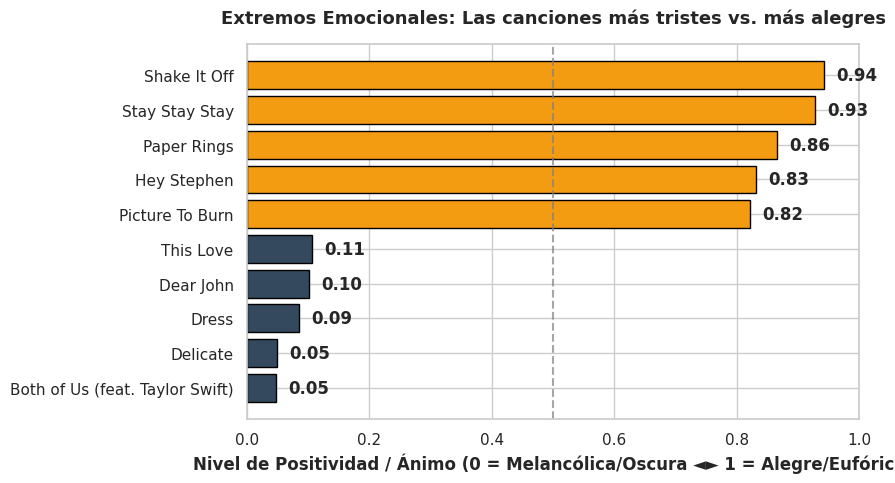

In [ ]:
# 1. Obtenemos las 5 con menor valence (tristes) y 5 con mayor valence (felices)
mas_tristes = canciones.sort_values(by='valence', ascending=True).head(5)
mas_felices = canciones.sort_values(by='valence', ascending=False).head(5)

podio_emocional = pd.concat([mas_tristes, mas_felices]).sort_values(by='valence', ascending=True)

# Usamos el nombre de columna detectado previamente o por defecto 'name'
col_cancion = columna_nombre if 'columna_nombre' in locals() and columna_nombre in canciones.columns else 'name'

plt.figure(figsize=(9, 5))
# Azul para tristeza, amarillo/naranja para felicidad
colores_animo = ['#34495E' if v < 0.5 else '#F39C12' for v in podio_emocional['valence']]

barras_animo = plt.barh(podio_emocional[col_cancion], podio_emocional['valence'], color=colores_animo, edgecolor='black')
plt.title('Extremos Emocionales: Las canciones más tristes vs. más alegres', fontsize=13, weight='bold', pad=15)
plt.xlabel('Nivel de Positividad / Ánimo (0 = Melancólica/Oscura ◄► 1 = Alegre/Eufórica)', weight='bold')
plt.xlim(0, 1)

# Línea divisoria en la mitad neutral
plt.axvline(x=0.5, linestyle='--', color='gray', alpha=0.7)

# Etiquetas con el valor exacto
for i, valor in enumerate(podio_emocional['valence']):
    plt.text(valor + 0.02, i, f"{valor:.2f}", va='center', weight='bold')

plt.tight_layout()
plt.show()

---
## Paso 12: Duración de las Canciones (Formato Corto vs. Tradicional)
¿Taylor Swift compone canciones cortas pensando en el streaming o mantiene estructuras largas y narrativas?

/tmp/ipykernel_1808/3704508614.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




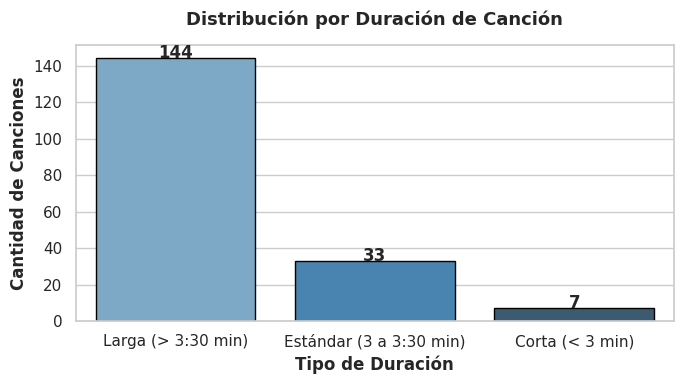

In [ ]:
# 1. Definir los bloques de tiempo
def clasificar_duracion(segundos):
    if segundos < 180:
        return 'Corta (< 3 min)'
    elif segundos <= 210:
        return 'Estándar (3 a 3:30 min)'
    else:
        return 'Larga (> 3:30 min)'

canciones['bloque_duracion'] = canciones['duracion_segundos'].apply(clasificar_duracion)

# 2. Contar canciones por bloque
conteo_duracion = canciones['bloque_duracion'].value_counts().reset_index()
conteo_duracion.columns = ['tipo', 'total']

plt.figure(figsize=(7, 4))
sns.barplot(
    data=conteo_duracion,
    x='tipo',
    y='total',
    palette='Blues_d',
    edgecolor='black'
)

plt.title('Distribución por Duración de Canción', fontsize=13, weight='bold', pad=15)
plt.xlabel('Tipo de Duración', weight='bold')
plt.ylabel('Cantidad de Canciones', weight='bold')

for i, valor in enumerate(conteo_duracion['total']):
    plt.text(i, valor + 0.2, str(valor), ha='center', weight='bold')

plt.tight_layout()
plt.show()

---
## Paso 13: El Reloj Interactivo de Cada Canción
En esta gráfica interactiva puedes explorar la duración exacta de todas las canciones en minutos y segundos pasando el cursor sobre cada punto:

In [ ]:
# 1. Aseguramos el cálculo de minutos y formato legible (ej. "3 min 28 s")
if 'duracion_minutos' not in canciones.columns and 'duracion_segundos' in canciones.columns:
    canciones['duracion_minutos'] = (canciones['duracion_segundos'] / 60).round(2)

canciones['tiempo_exacto'] = canciones['duracion_segundos'].apply(
    lambda s: f"{int(s // 60)} min {int(s % 60):02d} s"
)

# 2. Ordenamos las canciones de menor a mayor duración
canciones_ordenadas = canciones.sort_values(by='duracion_minutos', ascending=True).copy()

# Usamos el nombre de columna detectado de forma segura
col_cancion = columna_nombre if 'columna_nombre' in locals() and columna_nombre in canciones.columns else 'name'

# 3. Gráfica interactiva de duración
grafica_duracion = px.scatter(
    canciones_ordenadas,
    x='duracion_minutos',
    y=col_cancion,
    color='disco' if 'disco' in canciones_ordenadas.columns else None,
    hover_name=col_cancion,
    hover_data={
        'tiempo_exacto': True,
        'duracion_minutos': ':.2f',
        col_cancion: False
    },
    labels={
        'duracion_minutos': 'Duración (Minutos)',
        col_cancion: 'Canción',
        'tiempo_exacto': 'Tiempo',
        'disco': 'Disco / Era'
    },
    title='<b>Duración de Cada Canción</b><br><sup>Pasa el cursor por cada punto para ver el nombre y tiempo exacto</sup>',
    template='plotly_white',
    height=750  # Altura amplia para que se lean bien todos los títulos
)

# 4. Ajustamos el tamaño de los puntos para que resalten
grafica_duracion.update_traces(marker=dict(size=12, line=dict(width=1, color='black')))

# 5. Línea roja guía de referencia en los 3 minutos (estándar de la radio)
grafica_duracion.add_vline(
    x=3.0,
    line_dash="dash",
    line_color="crimson",
    annotation_text="Barrera de los 3:00 min",
    annotation_position="top right"
)

grafica_duracion.show()

---
## Paso 14: Tablas de Síntesis y Resumen Periodístico
Tres tablas que resumen de forma clara el comportamiento del catálogo:
1. **Impacto del formato:** Popularidad y ritmo según el tamaño de la canción.
2. **Polos opuestos:** Las canciones más acústicas frente a las más electrónicas.
3. **Resumen de escalas:** Las notas más usadas y su canción insignia.

In [ ]:
# 1. Detectamos de forma segura la columna del nombre de la canción
col_cancion = columna_nombre if 'columna_nombre' in locals() and columna_nombre in canciones.columns else 'name'

# 2. Agrupar por la categoría de duración usando la columna correcta
tabla_formatos = canciones.groupby('bloque_duracion' if 'bloque_duracion' in canciones.columns else 'format_category').agg(
    total_canciones=(col_cancion, 'count'),
    duracion_promedio_seg=('duracion_segundos', 'mean'),
    popularidad_promedio=('popularity', 'mean'),
    velocidad_promedio_bpm=('tempo', 'mean'),
    nivel_bailable=('danceability', 'mean')
).round(1).reset_index()

# 3. Renombrar columnas para presentación limpia
tabla_formatos.columns = [
    'Tipo de Formato', 'Total Canciones', 'Duración Media (s)',
    'Popularidad Media', 'Velocidad Media (BPM)', 'Bailabilidad'
]

print("=== TABLA 1: IMPACTO DEL FORMATO DE DURACIÓN ===")
display(tabla_formatos)

=== TABLA 1: IMPACTO DEL FORMATO DE DURACIÓN ===


,Tipo de Formato,Total Canciones,Duración Media (s),Popularidad Media,Velocidad Media (BPM),Bailabilidad
0,Corta (< 3 min),7,170.9,69.4,117.6,0.7
1,Estándar (3 a 3:30 min),33,199.6,65.4,119.9,0.6
2,Larga (> 3:30 min),144,249.9,67.1,125.6,0.6


In [ ]:
# 1. Detectamos dinámicamente qué columnas existen
col_cancion = columna_nombre if 'columna_nombre' in locals() and columna_nombre in canciones.columns else 'name'
col_album = 'disco' if 'disco' in canciones.columns else ('era_album' if 'era_album' in canciones.columns else None)

# Construimos la lista de columnas que realmente podemos extraer
columnas_disponibles = [col_cancion]
if col_album:
    columnas_disponibles.append(col_album)
columnas_disponibles.extend(['acousticness', 'energy'])

# 2. Las 5 más acústicas y las 5 más sintéticas/electrónicas
mas_acusticas = canciones.sort_values(by='acousticness', ascending=False).head(5)[columnas_disponibles].copy()
mas_acusticas['tipo_produccion'] = 'Acústica / Orgánica'

mas_sinteticas = canciones.sort_values(by='acousticness', ascending=True).head(5)[columnas_disponibles].copy()
mas_sinteticas['tipo_produccion'] = 'Sintética / Digital'

# 3. Unir ambas en una sola tabla de contraste
tabla_acustica_digital = pd.concat([mas_acusticas, mas_sinteticas])

# Ajustamos las columnas resultantes según si existía la columna de álbum o no
if col_album:
    tabla_acustica_digital.columns = ['Canción', 'Disco / Era', 'Nivel Acústico (0-1)', 'Energía (0-1)', 'Tipo de Sonido']
else:
    tabla_acustica_digital.columns = ['Canción', 'Nivel Acústico (0-1)', 'Energía (0-1)', 'Tipo de Sonido']

print("=== TABLA 2: POLOS OPUESTOS DE PRODUCCIÓN ===")
display(tabla_acustica_digital)

=== TABLA 2: POLOS OPUESTOS DE PRODUCCIÓN ===


,Canción,Nivel Acústico (0-1),Energía (0-1),Tipo de Sonido
103,It’s Nice To Have A Friend,0.971000,0.175,Acústica / Orgánica
64,evermore (feat. Bon Iver),0.937000,0.270,Acústica / Orgánica
102,New Year’s Day,0.921000,0.151,Acústica / Orgánica
8,champagne problems,0.920000,0.240,Acústica / Orgánica
81,peace,0.918000,0.272,Acústica / Orgánica
40,Change (Taylor’s Version),0.000191,0.815,Sintética / Digital
136,State Of Grace,0.000197,0.825,Sintética / Digital
97,Out Of The Woods,0.000743,0.841,Sintética / Digital
123,All You Had To Do Was Stay,0.001960,0.735,Sintética / Digital
66,22,0.002150,0.729,Sintética / Digital


In [ ]:
# 1. Agrupar por la tonalidad completa (Nota + Mayor/Menor)
col_tono = 'tonality' if 'tonality' in canciones.columns else 'nota_musical'
col_cancion = columna_nombre if 'columna_nombre' in locals() and columna_nombre in canciones.columns else 'name'

tabla_tonos_resumen = canciones.groupby(col_tono).agg(
    total_canciones=(col_cancion, 'count'),
    cancion_ejemplo=(col_cancion, 'first'),
    popularidad_promedio=('popularity', 'mean'),
    ritmo_promedio=('danceability', 'mean')
).sort_values(by='total_canciones', ascending=False).round(2).reset_index()

tabla_tonos_resumen.columns = [
    'Tonalidad Musical', 'Total Canciones', 'Canción Representativa',
    'Popularidad Media', 'Bailabilidad Media'
]

print("=== TABLA 3: RESUMEN DE ESCALAS Y TONALIDADES ===")
display(tabla_tonos_resumen.head(8))

=== TABLA 3: RESUMEN DE ESCALAS Y TONALIDADES ===


,Tonalidad Musical,Total Canciones,Canción Representativa,Popularidad Media,Bailabilidad Media
0,Sol (G),30,willow,66.30,0.60
1,Do (C),29,cardigan,70.24,0.61
2,Re (D),25,Love Story (Taylor’s Version),66.92,0.58
3,Fa (F),25,Blank Space,66.12,0.57
4,Mi (E),20,The Other Side Of The Door (Taylor’s Version),62.45,0.57
5,La (A),14,Delicate,70.29,0.61
6,Do# (C#),10,Breathe (feat. Colbie Caillat) (Taylor’s Version),64.50,0.56
7,La# (A#),9,Forever & Always (Taylor’s Version),59.78,0.55


---
## Conclusiones del Proyecto
1. **El valor de los datos en la música:** Las matemáticas y los datos de audio de Spotify confirman que la música pop no es aleatoria; sigue patrones de ritmo, energía y notas que conectan con millones de personas.
2. **La huella de Taylor Swift:** A diferencia de artistas puramente electrónicos o de radiofórmula corta, Taylor Swift conserva canciones con estructuras largas (más de 3:30 min) y una fuerte raíz en notas acústicas abiertas como Sol (G) y Do (C).
3. **El fenómeno del "Sad Banger":** Canciones emblemáticas demuestran que una letra triste o un tono melancólico pueden convivir perfectamente con ritmos bailables de gran energía.
